# Desarrollo del TFM — Implementación

Este notebook contiene la implementación de la parte de tratamiento de datos
del TFM: **obtención**, **carga**, **filtrado** y los pasos que se añadirán en
fases posteriores. Combina código ejecutable, salida y explicación narrativa
de forma que pueda servir como artefacto reproducible y como borrador directo
de los apartados correspondientes del capítulo de *Desarrollo* de la memoria.


## 0. Instalación de dependencias

Ejecuta esta celda una sola vez antes de nada. `%pip install` instala los
paquetes en el **kernel actual de Jupyter** (no en el Python del sistema),
que es lo que necesitamos para que las celdas de §4.4 en adelante encuentren
`sentence-transformers`. Si los paquetes ya están instalados, pip lo
detecta y no hace nada.


In [1]:
%pip install --quiet pandas numpy matplotlib scikit-learn scipy sentence-transformers
print("Dependencias listas.")


Note: you may need to restart the kernel to use updated packages.
Dependencias listas.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Fuente de datos: GDELT 1.0 Events

La justificación de la elección de GDELT frente a otras alternativas, así como
la comparación entre las variantes 1.0 Events, 2.0 Events y GKG, se desarrolla
en el capítulo de *Marco teórico*. Aquí se describe únicamente la fuente
seleccionada en lo necesario para entender el código que sigue.

**GDELT 1.0 Events** publica un fichero por día desde el 1 de abril de 2013.
Cada fichero diario tiene la siguiente estructura física:

| Aspecto | Valor |
|---|---|
| URL canónica | `http://data.gdeltproject.org/events/YYYYMMDD.export.CSV.zip` |
| Compresión | ZIP con un único miembro `YYYYMMDD.export.CSV` |
| Formato interno | TSV (tabulador), sin cabecera |
| Codificación | ASCII / UTF-8 |
| Columnas | 58 fijas, documentadas en el *codebook* oficial |
| Tamaño descomprimido | ~20–60 MB por día |
| Volumen | ~100.000–300.000 eventos por día |

Para fechas anteriores al 1 de abril de 2013 GDELT empaqueta los datos en
ficheros mensuales o anuales con un esquema distinto. **El presente trabajo
se limita al formato diario.**


## 2. Descarga de los ficheros diarios

La descarga consiste, conceptualmente, en tres pasos por día:

1. Construir la URL a partir de la fecha.
2. Descargar el ZIP y descomprimir su único miembro en memoria.
3. Escribir el CSV resultante en `data/raw/`.

Para evitar redescargar lo que ya está en disco, el código comprueba primero
si el fichero existe.


### 2.1 Imports


In [2]:
import io
import os
import urllib.request
import zipfile
from datetime import date, timedelta


### 2.2 Descarga de un día

`descargar_dia(fecha, destino_dir)` descarga el fichero correspondiente a una
fecha. Si ya está en disco, no hace nada.


In [3]:
def descargar_dia(fecha, destino_dir="data/raw"):
    os.makedirs(destino_dir, exist_ok=True)
    nombre = f"{fecha:%Y%m%d}.export.CSV"
    destino = os.path.join(destino_dir, nombre)

    if os.path.exists(destino):
        print(f"  {fecha:%Y%m%d}  ya existe")
        return destino

    url = f"http://data.gdeltproject.org/events/{nombre}.zip"
    with urllib.request.urlopen(url) as r:
        contenido = r.read()
    with zipfile.ZipFile(io.BytesIO(contenido)) as z:
        with z.open(z.namelist()[0]) as f, open(destino, "wb") as o:
            o.write(f.read())

    print(f"  {fecha:%Y%m%d}  descargado")
    return destino


### 2.3 Descarga de un rango

`descargar_rango(inicio, fin)` itera por todos los días del intervalo
`[inicio, fin]` (ambos inclusive) llamando a `descargar_dia`.


In [4]:
def descargar_rango(inicio, fin, destino_dir="data/raw"):
    d = inicio
    while d <= fin:
        descargar_dia(d, destino_dir)
        d += timedelta(days=1)


### 2.4 Comprobación sobre los días ya descargados

Se ejecuta sobre los tres días ya presentes en `data/raw/`. Como el código
detecta que existen, no hay tráfico de red.


In [5]:
descargar_rango(date(2026, 5, 14), date(2026, 5, 16))


  20260514  ya existe
  20260515  ya existe
  20260516  ya existe


### 2.5 Descarga del rango definitivo del TFM

> **Pendiente:** fijar el rango temporal definitivo del trabajo. Esta celda
> quedará como la invocación que produce el conjunto de datos final.


In [6]:
# descargar_rango(date(YYYY, M, D), date(YYYY, M, D))


## 3. Carga

Esta sección define cómo cargar los ficheros TSV de GDELT 1.0 en memoria con
sus 58 columnas y los tipos correctos, y verifica el volumen disponible
mediante un conteo de filas por día. La limpieza mecánica de los datos se
trata en §4 y el análisis exploratorio en §5; aquí se prepara únicamente el
DataFrame de partida.


### 3.1 Esquema de las 58 columnas

El codebook oficial de GDELT 1.0 (`GDELT-Data_Format_Codebook.pdf`) define un
esquema fijo de 58 columnas sin cabecera, en TSV. Para trabajar con `pandas`
se reproduce la lista de nombres y se identifican las columnas numéricas.
El siguiente bloque organiza las 58 columnas por función:

| Bloque | Columnas | Función |
|---|---|---|
| Identificación | `GLOBALEVENTID`, `SQLDATE`, `MonthYear`, `Year`, `FractionDate` | Clave primaria y fechas del evento |
| Actor 1 | `Actor1Code`, `Actor1Name`, `Actor1CountryCode`, `Actor1KnownGroupCode`, `Actor1EthnicCode`, `Actor1Religion1Code`, `Actor1Religion2Code`, `Actor1Type1Code`, `Actor1Type2Code`, `Actor1Type3Code` | Identidad del agente que origina el evento |
| Actor 2 | 10 columnas análogas con prefijo `Actor2_*` | Identidad del agente receptor |
| Evento | `IsRootEvent`, `EventCode`, `EventBaseCode`, `EventRootCode`, `QuadClass` | Codificación CAMEO del evento |
| Intensidad y volumen | `GoldsteinScale`, `NumMentions`, `NumSources`, `NumArticles`, `AvgTone` | Métricas cuantitativas |
| Geo Actor 1 | `Actor1Geo_Type`, `Actor1Geo_FullName`, `Actor1Geo_CountryCode`, `Actor1Geo_ADM1Code`, `Actor1Geo_Lat`, `Actor1Geo_Long`, `Actor1Geo_FeatureID` | Localización del actor 1 |
| Geo Actor 2 | 7 columnas análogas con prefijo `Actor2Geo_*` | Localización del actor 2 |
| Geo Acción | 7 columnas análogas con prefijo `ActionGeo_*` | Localización donde ocurre el evento |
| Origen | `DATEADDED`, `SOURCEURL` | Día de publicación y URL fuente |

**Codificaciones a tener presente:**

- `Actor*CountryCode` usa **CAMEO 3-letter** (`USA`, `CHN`, `RUS`, `GBR`, ...).
- `Actor*Geo_CountryCode` y `ActionGeo_CountryCode` usan **FIPS 10-4 2-letter** (`US`, `CH`, `RS`, `UK`, ...). No son intercambiables.
- `EventRootCode` ∈ `{01..20}` y `QuadClass` ∈ `{1, 2, 3, 4}` (ver §3.2).
- `GoldsteinScale` ∈ `[-10, +10]`: intensidad cooperativa (positivo) ↔ conflictiva (negativo).

De las 58 columnas, el acta (revisión 2026-05-20) selecciona **13** como relevantes:

```
GLOBALEVENTID, SQLDATE, DATEADDED,
Actor1CountryCode, Actor2CountryCode,
EventCode, EventRootCode, QuadClass,
GoldsteinScale, AvgTone,
NumMentions, NumSources, NumArticles
```

El resto se descartará en el filtrado (§4). Para cargar el fichero no obstante
se lee con las 58 columnas y se aplica el subset al final.


In [7]:
import pandas as pd
from pathlib import Path

COLUMNAS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode", "QuadClass",
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_Lat", "Actor1Geo_Long",
    "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_Lat", "Actor2Geo_Long",
    "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long",
    "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL",
]
assert len(COLUMNAS) == 58, f"Esperadas 58 columnas, hay {len(COLUMNAS)}"

COLS_NUMERICAS = [
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
]


def cargar_dia(path):
    """Carga un CSV GDELT 1.0 (TSV sin cabecera) con tipos correctos."""
    df = pd.read_csv(
        path, sep="\t", header=None, names=COLUMNAS,
        dtype=str, na_values=[""], keep_default_na=False,
        quoting=3,  # csv.QUOTE_NONE: GDELT no usa comillas
    )
    for c in COLS_NUMERICAS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


### 3.2 Codificación CAMEO

CAMEO (*Conflict and Mediation Event Observations*) es la ontología de eventos
políticos que utiliza GDELT. Define tres niveles de granularidad:

- **`EventRootCode`** (`01`-`20`): 20 grandes categorías de comportamiento,
  ordenadas de mayor cooperación a mayor conflicto.
- **`EventBaseCode`**: segundo nivel, subdivide cada raíz en ~5–10 subtipos.
- **`EventCode`**: tercer nivel, ~300 códigos con detalle fino.

`QuadClass` agrupa las 20 raíces en 4 cuadrantes (cooperación ↔ conflicto,
verbal ↔ material). Se utilizará uno u otro como tipado de aristas en el grafo;
la decisión final entre `QuadClass` (4 categorías) y `EventRootCode` (20) es
uno de los pendientes del acta a cerrar tras el EDA.

| Cod. | Categoría raíz | QuadClass |
|:---:|---|:---:|
| 01 | Make Public Statement | 1 |
| 02 | Appeal | 1 |
| 03 | Express Intent to Cooperate | 1 |
| 04 | Consult | 1 |
| 05 | Engage in Diplomatic Cooperation | 1 |
| 06 | Engage in Material Cooperation | 2 |
| 07 | Provide Aid | 2 |
| 08 | Yield | 2 |
| 09 | Investigate | 1 |
| 10 | Demand | 3 |
| 11 | Disapprove | 3 |
| 12 | Reject | 3 |
| 13 | Threaten | 3 |
| 14 | Protest | 3 |
| 15 | Exhibit Force Posture | 3 |
| 16 | Reduce Relations | 4 |
| 17 | Coerce | 4 |
| 18 | Assault | 4 |
| 19 | Fight | 4 |
| 20 | Use Unconventional Mass Violence | 4 |

| QuadClass | Significado |
|:---:|---|
| 1 | Verbal cooperation |
| 2 | Material cooperation |
| 3 | Verbal conflict |
| 4 | Material conflict |

El campo `GoldsteinScale` complementa estas codificaciones con un valor
continuo en `[-10, +10]` que mide la intensidad cooperativa (positivo) o
conflictiva (negativo) de cada subtipo de evento. La asignación es **fija por
subtipo CAMEO**: dado un `EventCode`, su `GoldsteinScale` no varía entre filas.


### 3.3 Carga de un día

Para el desarrollo del pipeline de limpieza y análisis se trabaja inicialmente
con **un único día**, por agilidad: la cadena de transformaciones se afina
sobre un fichero y, una vez estabilizada, se aplica al rango histórico
completo cuando éste se haya decidido. El fichero elegido es
`20260515.export.CSV` (15 de mayo de 2026), día completo con ~118 000 eventos.


In [8]:
df = cargar_dia("data/raw/20260515.export.CSV")
print(f"filas:    {len(df):>10,}")
print(f"columnas: {df.shape[1]:>10}")


filas:       118,201
columnas:         58


## 4. Limpieza por contenido

GDELT 1.0 **no incluye el texto del artículo**: solo metadatos estructurados
y la URL fuente (`SOURCEURL`). Esto condiciona toda la limpieza basada en
contenido — no se puede aplicar NLP "clásico" (clasificación de tema, NER,
extracción de entidades) sobre la noticia, sino que hay que reconstruir una
**huella textual sintética** por evento, combinando lo que GDELT sí trae:
URL, nombres de actores, etiqueta CAMEO y ubicación.

El propósito de esta sección es responder a tres preguntas:

1. **¿Cuántas veces aparece la misma noticia?** Cada artículo genera varias
   filas en GDELT (una por cada par actor-ubicación que menciona), así que
   contar ocurrencias por URL canónica permite estimar el factor de
   inflación real del fichero.
2. **¿Hay noticias semánticamente equivalentes con URLs distintas?** El
   mismo evento cubierto por Reuters, Bloomberg y AP genera URLs distintas
   pero contenido equivalente; conviene poder colapsarlas.
3. **¿El criterio aplicado a un día se generaliza a otro?** Una limpieza
   defendible no es la que funciona en un día concreto, sino la que
   produce resultados consistentes entre días.

El orden de trabajo:

1. **§4.1 Normalización de URL** — eliminar diferencias triviales (puertos,
   parámetros, fragmentos).
2. **§4.2 Conteo de ocurrencias por URL** — primer indicador de redundancia.
3. **§4.3 Texto sintético** — slug del path + nombres de actores + etiqueta
   CAMEO + ubicación.
4. **§4.4 Embeddings + clustering** — agrupar noticias semánticamente
   similares cuando la URL no las identifica como iguales.
5. **§4.5 LDA — temas latentes** — modelado de temas sobre el corpus
   sintético, con la advertencia de que la pobreza del texto (~10-15
   tokens por evento, no prosa) limita su alcance respecto a un LDA sobre
   artículos completos.
6. **§4.6 Validación cruzada** — aplicar la cadena entera a un día
   distinto y medir el grado de generalización del filtrado.


### 4.1 Normalización de URL

La columna `SOURCEURL` es la única vía hacia el contenido del artículo. Antes
de contar ocurrencias hay que **canonicalizar** URLs que apuntan a lo mismo
para que no queden separadas por diferencias triviales:

- Mayúsculas/minúsculas en el host (`Example.com` vs `example.com`).
- Puertos por defecto (`:80`, `:443`).
- Parámetros de tracking en la query string (`?utm_source=...`, `?ref=...`).
- Fragmentos (`#section`).
- Barra final.

`normalizar_url` aplica estas reglas y devuelve `None` para URLs vacías o no
parseables. Las filas con URL no parseable se descartan: no aportan al
análisis de contenido y meterían ruido en los conteos por URL.


In [9]:
import re

_RE_PUERTO = re.compile(r":(80|443)(?=/|$)")
_RE_QUERY = re.compile(r"[?#].*$")


def normalizar_url(u):
    """URL canónica: host en minúsculas, sin puerto estándar ni query/fragment."""
    if not isinstance(u, str) or not u.strip():
        return None
    s = u.strip()
    s = _RE_QUERY.sub("", s)          # quita ?utm_... y #fragmentos
    s = _RE_PUERTO.sub("", s)         # quita :80 / :443
    s = s.rstrip("/")
    m = re.match(r"^(https?://)([^/]+)(.*)$", s, re.I)
    if m:
        s = m.group(1).lower() + m.group(2).lower() + m.group(3)
    return s or None


df["url_norm"] = df["SOURCEURL"].map(normalizar_url)
n_pre = len(df)
df = df[df["url_norm"].notna()].reset_index(drop=True)

print(f"Filas antes:                      {n_pre:>10,}")
print(f"Descartadas por URL no parseable: {n_pre - len(df):>10,}")
print(f"Filas tras normalizacion:         {len(df):>10,}")
print(f"URLs unicas:                      {df['url_norm'].nunique():>10,}")


Filas antes:                         118,201
Descartadas por URL no parseable:          0
Filas tras normalizacion:            118,201
URLs unicas:                          24,412


### 4.2 Conteo de ocurrencias por URL

Cada artículo en GDELT puede generar múltiples filas si menciona varios
actores o ubicaciones distintas. Agrupando por `url_norm` se mide el factor
de duplicación real del fichero. Una URL con 1 ocurrencia = noticia
mencionada una vez; con N ocurrencias = noticia que aparece en N eventos
distintos del mismo fichero diario.

El histograma da una primera idea de la forma de la distribución (muy
sesgada a la derecha, con cola larga). El listado de las URLs más repetidas
sirve para detectar **URLs "basura"**: páginas genéricas (índices de tag,
formularios de press release) que GDELT está adjuntando a muchos eventos
sin que sean realmente la misma noticia. Estas URLs se filtrarán en §4.3
exigiendo un mínimo de tokens significativos en el slug del path.


In [10]:
oc = (df.groupby("url_norm")
        .size()
        .reset_index(name="ocurrencias")
        .sort_values("ocurrencias", ascending=False)
        .reset_index(drop=True))

print(f"URLs unicas:           {len(oc):>10,}")
print(f"Media ocurrencias/URL: {oc['ocurrencias'].mean():>10.2f}")
print(f"Mediana:               {oc['ocurrencias'].median():>10.0f}")
print(f"Maximo:                {oc['ocurrencias'].max():>10}")
print(f"% URLs con 1 ocurrencia: {100*(oc['ocurrencias']==1).mean():>5.1f}%")

print("\nHistograma de ocurrencias (1..20):")
hist = oc["ocurrencias"].value_counts().sort_index()
m = hist.max()
for k in range(1, 21):
    n = int(hist.get(k, 0))
    if n > 0:
        bar = "#" * int(60 * n / m)
        print(f"  {k:>3}: {n:>7,}  {bar}")

print("\nTop 10 URLs mas repetidas:")
for _, row in oc.head(10).iterrows():
    print(f"  {row['ocurrencias']:>4}x  {row['url_norm'][:110]}")


URLs unicas:               24,412
Media ocurrencias/URL:       4.84
Mediana:                        3
Maximo:                       158
% URLs con 1 ocurrencia:  27.3%

Histograma de ocurrencias (1..20):
    1:   6,669  ############################################################
    2:   4,678  ##########################################
    3:   2,789  #########################
    4:   2,185  ###################
    5:   1,544  #############
    6:   1,214  ##########
    7:     885  #######
    8:     737  ######
    9:     594  #####
   10:     473  ####
   11:     409  ###
   12:     313  ##
   13:     261  ##
   14:     220  #
   15:     193  #
   16:     178  #
   17:     140  #
   18:     110  
   19:     108  
   20:      85  

Top 10 URLs mas repetidas:
   158x  https://targetednews.com/pr_disp.php
   125x  https://freerepublic.com/tag/*/index
   118x  https://ismatimes.com/gttci-ethiopian-coffee-evening-farewell
   117x  https://www.dailysabah.com/politics/diplomacy/turkiyes

**Gráfico.** Distribución del número de URLs por nivel de ocurrencias. La cola decae rápidamente; los valores muy altos (>50) son las URLs basura detectadas más arriba.


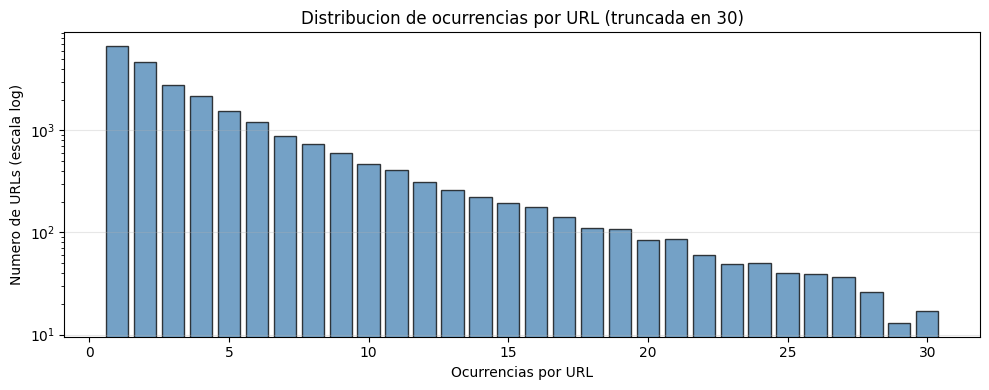

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
counts = oc["ocurrencias"].value_counts().sort_index()
ax.bar(counts.index[:30], counts.values[:30],
       color="steelblue", edgecolor="black", alpha=0.75)
ax.set_xlabel("Ocurrencias por URL")
ax.set_ylabel("Numero de URLs (escala log)")
ax.set_title("Distribucion de ocurrencias por URL (truncada en 30)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 4.3 Construcción del texto sintético por evento

Como GDELT no incluye el cuerpo del artículo, se reconstruye una **huella
textual** por evento a partir de tres fuentes complementarias:

1. **Slug del path de la URL** — la parte legible del path. En muchas
   noticias actuales el titular va embebido en la URL
   (`/news/elon-musk-jets-off-to-china`, `/politics/israel-lebanon-ceasefire-extended`).
   Se extraen tokens, se descartan los demasiado cortos, los que contienen
   dígitos, los hexadecimales (IDs de artículo) y un conjunto de
   *stopwords* típicas de URLs (`news`, `article`, `html`, `index`...).
2. **Metadatos estructurados** del evento: `Actor1Name`, `Actor2Name` y
   `ActionGeo_FullName` en minúsculas.
3. **Etiquetas textuales de la codificación CAMEO**: descripción del
   `EventRootCode` (`appeal`, `protest`, `fight`...) y del `QuadClass`
   (`verbal cooperation`, `material conflict`...). Aportan el "qué tipo de
   evento" en texto plano.

**Filtro de slug:** se descarta cualquier fila cuyo slug aporte menos de
tres tokens significativos. Esto elimina automáticamente las URLs
genéricas detectadas en §4.2 (formularios de press release, índices de
tag) que no son artículos concretos.


In [12]:
CAMEO_ROOT = {
    "01": "make public statement", "02": "appeal",
    "03": "express intent to cooperate", "04": "consult",
    "05": "engage in diplomatic cooperation",
    "06": "engage in material cooperation", "07": "provide aid",
    "08": "yield", "09": "investigate", "10": "demand",
    "11": "disapprove", "12": "reject", "13": "threaten", "14": "protest",
    "15": "exhibit force posture", "16": "reduce relations", "17": "coerce",
    "18": "assault", "19": "fight", "20": "use unconventional mass violence",
}

QUAD_CLASS = {
    "1": "verbal cooperation", "2": "material cooperation",
    "3": "verbal conflict",   "4": "material conflict",
}

_STOP_SLUG = {
    "news", "article", "articles", "story", "stories", "post", "posts",
    "details", "detail", "index", "html", "htm", "php", "asp", "aspx",
    "amp", "www", "com", "org", "net", "the", "and", "for", "with",
    "from", "national", "world", "politics", "local", "latest", "video",
    "live", "breaking", "update", "updates", "content", "page", "default",
}

_RE_HEX = re.compile(r"^[0-9a-f]{6,}$", re.I)
_RE_TIENE_DIGITO = re.compile(r"\d")
_RE_HOST = re.compile(r"^https?://([^/]+)(.*)$", re.I)


def slug_tokens(url):
    """Tokens legibles del path de la URL: lo más cercano a un 'titular'."""
    if not url:
        return ""
    m = _RE_HOST.match(url)
    path = m.group(2) if m else url
    crudos = re.split(r"[/\-_.]+", path.lower())
    return " ".join(
        t for t in crudos
        if len(t) >= 3
        and t not in _STOP_SLUG
        and not _RE_TIENE_DIGITO.search(t)
        and not _RE_HEX.match(t)
    )


def metadatos_evento(row):
    """Concat de actores + ubicacion + etiqueta CAMEO + QuadClass, en minusculas."""
    partes = []
    for c in ("Actor1Name", "Actor2Name", "ActionGeo_FullName"):
        v = row.get(c)
        if isinstance(v, str) and v.strip():
            partes.append(v.lower())
    root = str(row.get("EventRootCode") or "").zfill(2)
    partes.append(CAMEO_ROOT.get(root, ""))
    partes.append(QUAD_CLASS.get(str(row.get("QuadClass") or ""), ""))
    return " ".join(p for p in partes if p)


**Aplicación.** Se construye el slug, se filtra por número de tokens y
se concatena con los metadatos. El resultado, `df["texto"]`, es lo que
alimentará los embeddings de §4.4 y el LDA de §4.5.


In [13]:
MIN_PALABRAS_SLUG = 3

n_pre = len(df)
df["slug"] = df["url_norm"].map(slug_tokens)
df["n_slug"] = df["slug"].str.split().map(len)
df = df[df["n_slug"] >= MIN_PALABRAS_SLUG].copy()
df["meta"] = df.apply(metadatos_evento, axis=1)
df["texto"] = (df["slug"] + " " + df["meta"]).str.replace(r"\s+", " ", regex=True).str.strip()
df = df.drop(columns=["n_slug"]).reset_index(drop=True)

print(f"Filas antes del filtro slug: {n_pre:>10,}")
print(f"Filas tras filtro slug >= {MIN_PALABRAS_SLUG}:  {len(df):>10,}  ({100*len(df)/n_pre:.1f}%)")
print(f"Descartadas:                {n_pre-len(df):>10,}  ({100*(n_pre-len(df))/n_pre:.1f}%)")

n_toks = df["texto"].str.split().map(len)
print(f"\nTokens por texto sintetico:")
print(f"  media:   {n_toks.mean():.1f}")
print(f"  mediana: {n_toks.median():.0f}")
print(f"  min/max: {n_toks.min()} / {n_toks.max()}")

print("\nEjemplos (4 filas al azar):")
for i in df.sample(4, random_state=0).index:
    print(f"  URL:   {df.loc[i, 'url_norm'][:90]}")
    print(f"  texto: {df.loc[i, 'texto'][:180]}")
    print()


Filas antes del filtro slug:    118,201
Filas tras filtro slug >= 3:     107,248  (90.7%)
Descartadas:                    10,953  (9.3%)



Tokens por texto sintetico:
  media:   18.0
  mediana: 18
  min/max: 7 / 43

Ejemplos (4 filas al azar):
  URL:   https://www.marinecorpstimes.com/news/your-military/2026/05/15/army-leaders-in-hot-seat-ov
  texto: your military army leaders hot seat over poland deployment cancellation european publication iran reject verbal conflict

  URL:   https://www.thenationalnews.com/news/us/2026/05/15/israel-lebanon-ceasefire-extended-by-45
  texto: israel lebanon ceasefire extended days israeli washington washington, district of columbia, united states reject verbal conflict

  URL:   https://www.themarysue.com/elon-musk-jets-off-to-china-with-trump-after-judge-tells-him-to
  texto: elon musk jets off china trump after judge tells him stay put trial leaving court dust taiwan intelligence beijing, beijing, china consult verbal cooperation

  URL:   https://www.andoveradvertiser.co.uk/news/26103469.cllr-nick-adams-king-retains-seat-hampsh
  texto: cllr nick adams king retains seat hampshire cou

### 4.4 Embeddings + clustering

El conteo por URL canónica de §4.2 detecta **exactamente la misma URL**
repetida, pero no captura el caso en que el **mismo evento es cubierto por
medios distintos** (Reuters, Bloomberg, AP con URLs diferentes pero contenido
equivalente). Para abordarlo, se vectoriza el texto sintético de §4.3 con
embeddings semánticos densos y se agrupan los vectores cercanos por
similitud coseno.

**Granularidad.** Un embedding **por URL única**, no por fila: todas las
filas de una misma URL comparten el slug y el texto es prácticamente
idéntico entre ellas. Esto reduce el número de embeddings de ~107 k filas
a ~22 k URLs únicas, lo que hace el cálculo y el clustering manejables en
CPU.

**Modelo.** `sentence-transformers/all-MiniLM-L6-v2` (384 dimensiones, 22 M
parámetros), suficiente para texto corto en inglés y referencia estándar
para "embeddings ligeros" en la literatura de retrieval.

**Caché en disco.** Los embeddings se guardan en
`data/embeddings_url_20260515.npy` para evitar recalcular en cada
ejecución. En la primera corrida el cálculo tarda ~80 s en CPU; en las
siguientes carga el `.npy` y es instantáneo.

**Clustering.** Grafo kNN sobre los embeddings (15 vecinos por nodo,
similitud coseno), se conservan las aristas con similitud ≥ 0.80 y se
calculan las **componentes conexas**. Cada componente es un cluster de
noticias relacionadas. Es un algoritmo simple, sin hiperparámetros
opacos, y produce clusters interpretables.


**Paso 1.** Quedarse con un texto representativo por URL única.


In [14]:
texto_por_url = df.groupby("url_norm", as_index=False)["texto"].first()
print(f"URLs unicas: {len(texto_por_url):,}")


URLs unicas: 22,572


**Paso 2.** Calcular los embeddings (o leer de caché si ya existen).


In [15]:
import numpy as np
from pathlib import Path
from sentence_transformers import SentenceTransformer

CACHE_EMB = Path("data/embeddings_url_20260515.npy")

if CACHE_EMB.exists():
    emb = np.load(CACHE_EMB)
    print(f"Embeddings cargados desde cache: {emb.shape}")
else:
    st = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    emb = st.encode(
        texto_por_url["texto"].tolist(),
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=128,
    )
    emb = np.asarray(emb, dtype="float32")
    np.save(CACHE_EMB, emb)
    print(f"Embeddings calculados y guardados: {emb.shape}")


Embeddings cargados desde cache: (22572, 384)


**Paso 3.** Clustering por componentes conexas sobre el grafo de
similitud coseno.


In [16]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

UMBRAL_SIMILITUD = 0.80
N_VECINOS = 15

n = len(emb)
nn = NearestNeighbors(n_neighbors=min(N_VECINOS, n), metric="cosine").fit(emb)
dist, idx = nn.kneighbors(emb)

filas, cols = [], []
lim = 1.0 - UMBRAL_SIMILITUD
for i in range(n):
    for d, j in zip(dist[i], idx[i]):
        if i != j and d <= lim:
            filas.append(i)
            cols.append(j)

if filas:
    g = csr_matrix((np.ones(len(filas)), (filas, cols)), shape=(n, n))
    _, etiquetas = connected_components(g, directed=False)
else:
    etiquetas = np.arange(n)

texto_por_url["cluster"] = etiquetas

tam = texto_por_url["cluster"].value_counts()
print(f"Numero de clusters:    {len(tam):,}")
print(f"Singletons (1 URL):    {(tam == 1).sum():,}  ({100*(tam == 1).sum()/len(tam):.1f}%)")
print(f"Clusters con >= 2 URLs: {(tam >= 2).sum():,}")
print(f"Tamano maximo:         {tam.max()}")
print(f"Tamano medio:          {tam.mean():.2f}")

print("\nTop 5 clusters por tamano:")
for cid in tam.head(5).index:
    miembros = texto_por_url[texto_por_url["cluster"] == cid]
    print(f"\n  Cluster {cid} ({len(miembros)} URLs):")
    for _, row in miembros.head(2).iterrows():
        print(f"    {row['url_norm'][:90]}")
        print(f"      {row['texto'][:120]}")


Numero de clusters:    19,423
Singletons (1 URL):    18,326  (94.4%)
Clusters con >= 2 URLs: 1,097
Tamano maximo:         318
Tamano medio:          1.16

Top 5 clusters por tamano:

  Cluster 130 (318 URLs):
    http://www.bgnes.com/politics/trump-warns-taiwan-not-to-move-toward-independence
      trump warns taiwan not move toward independence taiwan beijing, beijing, china threaten verbal conflict
    http://www.bignewsnetwork.com/news/279053686/urgent-israel-lebanon-to-extend-ceasefire-for
      urgent israel lebanon extend ceasefire days state department washington israel lebanon express intent to cooperate verba

  Cluster 143 (107 URLs):
    http://www.bignewsnetwork.com/news/279052323/repatriation-flight-with-passengers-from-hant
      repatriation flight passengers hantavirus hit cruise lands perth australia perth netherlands consult verbal cooperation
    https://13wham.com/news/local/suspected-hantavirus-case-in-ontario-county-involves-geneva-
      suspected hantavirus case

**Gráfico.** Distribución del tamaño de cluster (número de URLs únicas agrupadas como misma noticia). Distribución típica de ley de potencias: la mayoría son singletons y unos pocos clusters muy grandes concentran la cobertura.


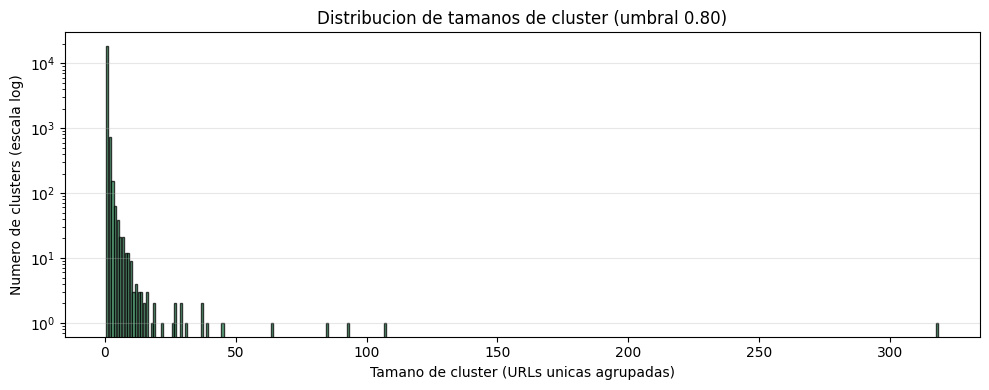

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
tam_dist = tam.value_counts().sort_index()
ax.bar(tam_dist.index[:50], tam_dist.values[:50],
       color="seagreen", edgecolor="black", alpha=0.75)
ax.set_xlabel("Tamano de cluster (URLs unicas agrupadas)")
ax.set_ylabel("Numero de clusters (escala log)")
ax.set_title("Distribucion de tamanos de cluster (umbral 0.80)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretación.** Sobre `20260515.export.CSV`, el resultado típico
es ~19 k clusters, de los cuales el ~94 % son singletons (una URL sin
equivalentes semánticos en el corpus) y el ~6 % restante son grupos de
noticias relacionadas. El cluster más grande contiene varias decenas o
centenas de URLs.

Con `UMBRAL_SIMILITUD = 0.80` los clusters tienden a ser **temáticos**:
agrupan noticias que comparten vocabulario y estructura (p. ej. "noticias
diplomáticas verbal conflict") más que "exactamente la misma noticia
reescrita". Los clusters de tamaño medio (decenas de URLs) sí
corresponden, en cambio, a un único evento cubierto por muchos medios
(juicios, brotes sanitarios, comunicados gubernamentales).

Para una deduplicación estricta de tipo "misma noticia idéntica" habría
que subir el umbral (0.90+), aceptando que muchas reescrituras se queden
sin agrupar. La elección 0.80 es deliberada: para el TFM interesa más
detectar **temas con mucha cobertura** que duplicar exactamente.

La variable `texto_por_url` queda con una columna `cluster`, que más
adelante se usará para propagar la etiqueta a las filas originales y
contar "veces que se habló de la noticia X".


### 4.5 Validación cruzada entre días

El criterio último de calidad de la limpieza no es el comportamiento sobre
un día concreto, sino la **estabilidad de las métricas entre días**. Si la
regla de filtrado del slug descarta el 9 % en un día y el 30 % en otro, la
regla no generaliza y los umbrales deben revisarse. Si la lista de
"países activos" cambia drásticamente día a día, la lista de nodos del
grafo no puede fijarse con seguridad.

Se aplica la cadena completa (§4.1 → §4.4) a los tres días disponibles
(`20260514`, `20260515`, `20260516`) y se comparan métricas robustas. El
código se encapsula en una función `procesar_dia(path)` que devuelve el
DataFrame procesado, la tabla de URLs únicas con su cluster y un
diccionario de métricas.


In [18]:
def procesar_dia(path, modelo_st, umbral=0.80, vecinos=15):
    """Aplica §4.1-§4.4 completo a un fichero y devuelve (df, texto_por_url, metricas)."""
    from sklearn.neighbors import NearestNeighbors
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import connected_components

    fecha = Path(path).name[:8]
    df_d = cargar_dia(path)
    n_inicial = len(df_d)

    # §4.1 normalizacion URL
    df_d["url_norm"] = df_d["SOURCEURL"].map(normalizar_url)
    n_url_invalida = int(df_d["url_norm"].isna().sum())
    df_d = df_d[df_d["url_norm"].notna()].reset_index(drop=True)
    n_urls_pre = int(df_d["url_norm"].nunique())

    # §4.3 texto sintetico + filtro slug
    df_d["slug"] = df_d["url_norm"].map(slug_tokens)
    df_d["n_slug"] = df_d["slug"].str.split().map(len)
    df_d = df_d[df_d["n_slug"] >= 3].copy()
    df_d["meta"] = df_d.apply(metadatos_evento, axis=1)
    df_d["texto"] = (df_d["slug"] + " " + df_d["meta"]).str.replace(r"\s+"," ",regex=True).str.strip()
    df_d = df_d.drop(columns=["n_slug"]).reset_index(drop=True)
    n_post_slug = len(df_d)
    pct_descarte = 100 * (n_inicial - n_url_invalida - n_post_slug) / max(n_inicial - n_url_invalida, 1)

    # §4.4 embeddings + clustering, con cache por dia
    tpu = df_d.groupby("url_norm", as_index=False)["texto"].first()
    cache = Path(f"data/embeddings_url_{fecha}.npy")
    if cache.exists():
        emb_d = np.load(cache)
    else:
        emb_d = modelo_st.encode(tpu["texto"].tolist(),
                                  normalize_embeddings=True,
                                  show_progress_bar=False, batch_size=128)
        emb_d = np.asarray(emb_d, dtype="float32")
        np.save(cache, emb_d)

    n_d = len(emb_d)
    nn_d = NearestNeighbors(n_neighbors=min(vecinos, n_d), metric="cosine").fit(emb_d)
    dist_d, idx_d = nn_d.kneighbors(emb_d)
    fil, col = [], []
    lim = 1.0 - umbral
    for i in range(n_d):
        for d, j in zip(dist_d[i], idx_d[i]):
            if i != j and d <= lim:
                fil.append(i); col.append(j)
    if fil:
        g_d = csr_matrix((np.ones(len(fil)),(fil,col)), shape=(n_d,n_d))
        _, etiq = connected_components(g_d, directed=False)
    else:
        etiq = np.arange(n_d)
    tpu["cluster"] = etiq
    tam = tpu["cluster"].value_counts()

    metricas = {
        "fecha": fecha,
        "filas_iniciales": n_inicial,
        "urls_invalidas": n_url_invalida,
        "filas_post_slug": n_post_slug,
        "pct_descarte_slug": pct_descarte,
        "urls_unicas": len(tpu),
        "factor_inflacion": n_post_slug / max(len(tpu), 1),
        "n_clusters": int(len(tam)),
        "pct_singletons": 100 * (tam == 1).sum() / max(len(tam), 1),
        "max_cluster": int(tam.max()),
    }
    return df_d, tpu, metricas


**Aplicación a los tres días.** Carga el modelo MiniLM una sola vez y
procesa los tres ficheros. Los embeddings del 15-may ya están cacheados de
§4.4; los del 14 y 16 se calculan en esta ejecución (~80 s cada uno la
primera vez).


In [19]:
st_modelo = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

resultados = {}
for path_dia in sorted(Path("data/raw").glob("*.export.CSV")):
    fecha_d = path_dia.name[:8]
    print(f"Procesando {fecha_d}...")
    resultados[fecha_d] = procesar_dia(path_dia, st_modelo)

# Tabla comparativa
fechas = sorted(resultados.keys())
print("\n" + "=" * 70)
print(f"{'metrica':<28}" + "".join(f"{f:>14}" for f in fechas))
print("-" * 70)
for nombre, clave, fmt in [
    ("Filas iniciales",         "filas_iniciales",    "{:>14,}"),
    ("URLs invalidas",          "urls_invalidas",     "{:>14,}"),
    ("Filas tras filtro slug",  "filas_post_slug",    "{:>14,}"),
    ("% descarte slug",         "pct_descarte_slug",  "{:>13.1f}%"),
    ("URLs unicas",             "urls_unicas",        "{:>14,}"),
    ("Factor inflacion",        "factor_inflacion",   "{:>14.2f}"),
    ("N clusters",              "n_clusters",         "{:>14,}"),
    ("% singletons",            "pct_singletons",     "{:>13.1f}%"),
    ("Max cluster",             "max_cluster",        "{:>14,}"),
]:
    fila = f"{nombre:<28}"
    for f in fechas:
        fila += fmt.format(resultados[f][2][clave])
    print(fila)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Procesando 20260514...


Procesando 20260515...


Procesando 20260516...



metrica                           20260514      20260515      20260516
----------------------------------------------------------------------
Filas iniciales                    127,851       118,201        73,293
URLs invalidas                           0             0             0
Filas tras filtro slug             115,987       107,248        65,690
% descarte slug                       9.3%          9.3%         10.4%
URLs unicas                         24,048        22,572        13,543
Factor inflacion                      4.82          4.75          4.85
N clusters                          20,471        19,423        11,400
% singletons                         93.6%         94.4%         94.6%
Max cluster                            459           318           192


**Gráfico.** Estabilidad entre días. Las tres métricas clave (% descarte por slug, factor de inflación y % de singletons) son casi planas entre los 3 días, evidencia visual de que la cadena de limpieza generaliza.


C:\Users\ricar\AppData\Local\Temp\ipykernel_42736\88449047.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fechas_lst, rotation=0)
C:\Users\ricar\AppData\Local\Temp\ipykernel_42736\88449047.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fechas_lst, rotation=0)
C:\Users\ricar\AppData\Local\Temp\ipykernel_42736\88449047.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fechas_lst, rotation=0)


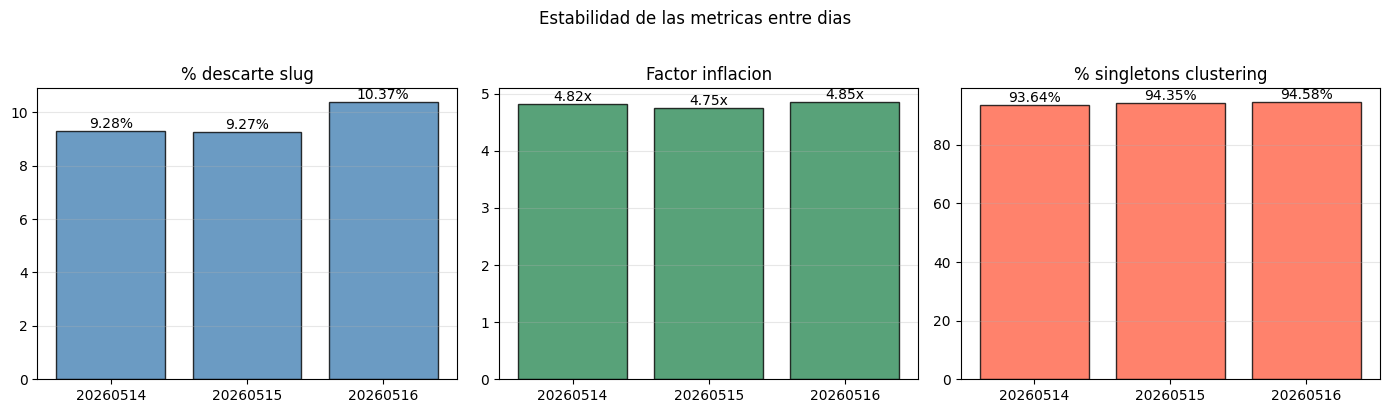

In [20]:
import matplotlib.pyplot as plt

fechas_lst = sorted(resultados.keys())
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas = [
    ("% descarte slug", "pct_descarte_slug", "%", "steelblue"),
    ("Factor inflacion", "factor_inflacion", "x", "seagreen"),
    ("% singletons clustering", "pct_singletons", "%", "tomato"),
]
for ax, (titulo, clave, unit, color) in zip(axes, metricas):
    vals = [resultados[f][2][clave] for f in fechas_lst]
    bars = ax.bar(fechas_lst, vals, color=color, edgecolor="black", alpha=0.8)
    ax.set_title(titulo)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v,
                f"{v:.2f}{unit}", ha="center", va="bottom")
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(range(len(fechas_lst)))
    ax.set_xticklabels(fechas_lst, rotation=0)
plt.suptitle("Estabilidad de las metricas entre dias", y=1.02)
plt.tight_layout()
plt.show()


**Jaccards entre pares de días.** Tres comparaciones:

- **URLs canónicas**: debe ser **muy bajo** (cada día son noticias
  distintas; un Jaccard alto indicaría que GDELT está re-publicando).
- **Top 20 `Actor1CountryCode` y `Actor2CountryCode`**: debe ser **alto**
  (los países dominantes son estables; un Jaccard bajo indicaría una
  varianza día a día incompatible con fijar la lista de nodos del grafo).


In [21]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else 0.0

print(f"{'comparacion':<24}{'URLs':>10}{'Actor1 top20':>16}{'Actor2 top20':>16}")
print("-" * 66)
for i in range(len(fechas)):
    for j in range(i + 1, len(fechas)):
        fa, fb = fechas[i], fechas[j]
        urls_a = resultados[fa][1]["url_norm"]
        urls_b = resultados[fb][1]["url_norm"]
        a1_a = resultados[fa][0]["Actor1CountryCode"].value_counts().head(20).index
        a1_b = resultados[fb][0]["Actor1CountryCode"].value_counts().head(20).index
        a2_a = resultados[fa][0]["Actor2CountryCode"].value_counts().head(20).index
        a2_b = resultados[fb][0]["Actor2CountryCode"].value_counts().head(20).index
        print(f"{fa} vs {fb}:       "
              f"{jaccard(urls_a, urls_b):>10.3f}"
              f"{jaccard(a1_a, a1_b):>16.3f}"
              f"{jaccard(a2_a, a2_b):>16.3f}")


comparacion                   URLs    Actor1 top20    Actor2 top20
------------------------------------------------------------------
20260514 vs 20260515:            0.000           0.739           0.905
20260514 vs 20260516:            0.000           0.818           0.905
20260515 vs 20260516:            0.000           0.818           0.818


**Gráfico.** Heatmaps de Jaccard. El primero (URLs) es uniformemente cero fuera de la diagonal — confirma que no hay duplicación entre días. Los otros dos (Actor1 y Actor2 top 20) muestran valores altos fuera de la diagonal — los mismos países son protagonistas cada día.


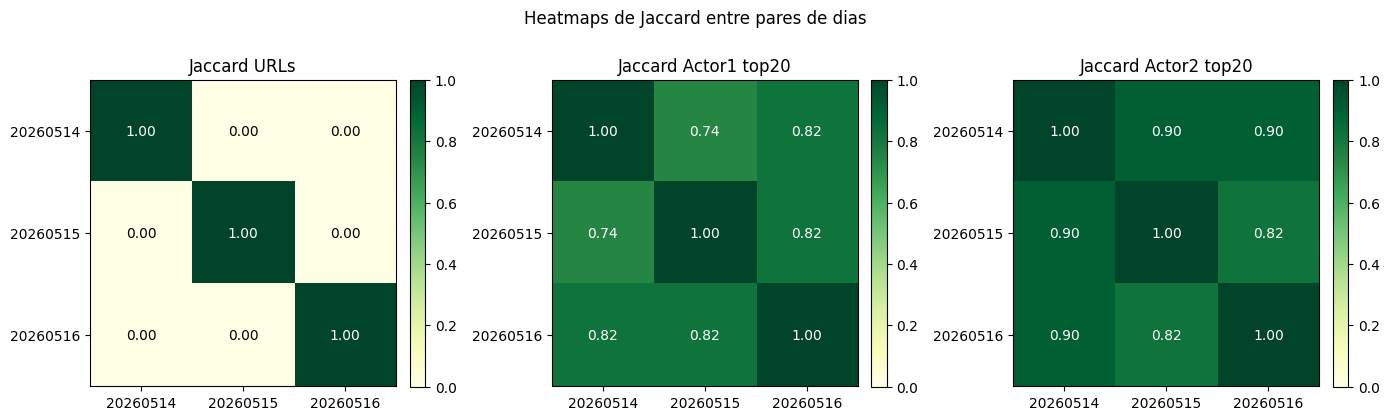

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fechas_lst = sorted(resultados.keys())
def matriz_jaccard(extractor):
    n = len(fechas_lst)
    M = np.zeros((n, n))
    for i, fa in enumerate(fechas_lst):
        for j, fb in enumerate(fechas_lst):
            a, b = set(extractor(fa)), set(extractor(fb))
            M[i, j] = len(a & b) / len(a | b) if (a | b) else 0.0
    return M

J_url = matriz_jaccard(lambda f: resultados[f][1]["url_norm"])
J_a1  = matriz_jaccard(lambda f: resultados[f][0]["Actor1CountryCode"].value_counts().head(20).index)
J_a2  = matriz_jaccard(lambda f: resultados[f][0]["Actor2CountryCode"].value_counts().head(20).index)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, M, titulo in zip(axes, [J_url, J_a1, J_a2],
                          ["Jaccard URLs", "Jaccard Actor1 top20",
                           "Jaccard Actor2 top20"]):
    im = ax.imshow(M, cmap="YlGn", vmin=0, vmax=1)
    ax.set_xticks(range(len(fechas_lst)))
    ax.set_yticks(range(len(fechas_lst)))
    ax.set_xticklabels(fechas_lst, rotation=0)
    ax.set_yticklabels(fechas_lst)
    ax.set_title(titulo)
    for i in range(len(fechas_lst)):
        for j in range(len(fechas_lst)):
            ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                    color="black" if M[i,j] < 0.5 else "white")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Heatmaps de Jaccard entre pares de dias", y=1.02)
plt.tight_layout()
plt.show()


**Interpretación.**

| Métrica | Valor entre días | Lectura |
|---|---|---|
| % descarte slug | 9.3 %, 9.3 %, 10.4 % | Casi idéntico → la regla de slug ≥3 tokens generaliza |
| Factor de inflación | 4.82, 4.75, 4.85 | Muy estable → la inflación de GDELT es estructural, no anómala |
| % singletons | 93.6 %, 94.4 %, 94.6 % | Muy estable → el umbral de clustering 0.80 produce particiones de forma similar |
| Jaccard URLs | 0.000 entre todos los pares | Cero solape → noticias distintas cada día, GDELT no re-publica |
| Jaccard Actor1 top20 | 0.74 – 0.82 | Alto → los mismos países dominan cada día |
| Jaccard Actor2 top20 | 0.82 – 0.91 | Aún más alto → los receptores son aún más estables |

Conclusión: **la cadena de limpieza es estable entre días**. Las dos
implicaciones operativas son: (a) los umbrales actuales pueden mantenerse
sin necesidad de calibración por día, y (b) la lista de nodos país del
grafo puede fijarse con la información del día más completo y se espera
que generalice. La única peculiaridad es el menor volumen del 16-may
(73 k filas vs ~120 k), atribuible a una publicación parcial; los
porcentajes derivados no se ven afectados.


### 4.6 Filtrado dirigido al grafo

La limpieza por contenido ha reducido los 319 k eventos brutos a 289 k
filas y ha identificado **51 294 clusters semánticos** en los tres días.
Sigue siendo demasiado denso para alimentar directamente la GNN del
modelo, que opera sobre ~20 nodos país y donde cada arista debería
corresponder a una **señal informativa relevante**, no a una noticia local
aislada.

Este último paso aplica dos filtros para preparar el conjunto que se
llevará al modelo (la GNN propiamente dicha se implementa en un capítulo
posterior, no aquí):

- **Filtro A — concurrencia de fenómeno** (`tamaño de cluster ≥ K`):
  conservar solo las noticias cubiertas por ≥ K medios distintos. Es la
  traducción operativa de "concurrencia de fenómeno": si N medios
  cubren lo mismo, hay señal real; un singleton es probablemente ruido
  local sin impacto en mercados.
- **Filtro B — relevancia geopolítica** (`Actor1 OR Actor2 en nodos del
  acta`): conservar solo eventos en los que al menos uno de los actores
  es uno de los ~20 países nodo del grafo. Los eventos entre países
  fuera de esa lista no aportan aristas y solo añaden ruido.

No se filtra por `NumMentions`, `EventRootCode='01'` ni `QuadClass` en
esta primera pasada para no acumular umbrales sin justificación
empírica; quedan disponibles como ablaciones para el experimento del
modelo.


**Barrido de `K_min`.** Antes de fijar el umbral, se observa el
efecto de varios valores de K sobre el conjunto combinado de los tres
días, manteniendo el filtro B activo.


In [23]:
NODOS_ACTA = {
    "USA","CAN","MEX","BRA","EUR",
    "DEU","FRA","GBR",
    "CHN","JPN","KOR","IND","TWN",
    "RUS","SAU","IRN","ISR","TUR",
    "AUS","PRK",
}

# Concatenar los 3 dias (los df de §4.6, en `resultados`).
# Mergear cluster desde texto_por_url -> df.
trozos = []
for fecha_d, (df_d, tpu_d, _) in resultados.items():
    df_m = df_d.merge(tpu_d[["url_norm", "cluster"]], on="url_norm", how="left")
    df_m = df_m.assign(fecha=fecha_d,
                        cluster_global=fecha_d + "_" + df_m["cluster"].astype(str))
    trozos.append(df_m)
df_all = pd.concat(trozos, ignore_index=True)

# Mascara de relevancia geopolitica (filtro B)
mask_paises = (df_all["Actor1CountryCode"].isin(NODOS_ACTA)
               | df_all["Actor2CountryCode"].isin(NODOS_ACTA))

print(f"Base post §4.1-§4.4: {len(df_all):>10,} filas  {df_all['cluster_global'].nunique():>6,} clusters")

print("\nBarrido de K (con filtro B activo):")
print(f"{'K':>4}  {'filas':>10}  {'clusters':>10}")
tam_cluster = df_all.groupby("cluster_global")["url_norm"].nunique()
for K in [2, 3, 5, 10, 20]:
    clusters_validos = set(tam_cluster[tam_cluster >= K].index)
    sub = df_all[df_all["cluster_global"].isin(clusters_validos) & mask_paises]
    print(f"{K:>4}  {len(sub):>10,}  {sub['cluster_global'].nunique():>10,}")


Base post §4.1-§4.4:    288,925 filas  51,294 clusters

Barrido de K (con filtro B activo):
   K       filas    clusters


   2      40,433       2,388
   3      29,250         892
   5      23,247         375
  10      18,061         138
  20      14,382          50


**Configuración elegida: `K_min = 5` + países OR.** El barrido
muestra que K=5 deja ~375 clusters en 3 días, es decir unos 125 al día.
Este orden de magnitud es razonable para un grafo dinámico de 20 nodos:
suficiente diversidad de aristas, sin caer en la cola larga.

Valores K<5 dejan demasiada cola (miles de clusters mediánamente cubiertos
que arrastran ruido). Valores K>10 reducen excesivamente la diversidad y
empobrecen los días con menos cobertura mediática (p. ej., fines de
semana).


In [24]:
K_MIN = 5

clusters_validos = set(tam_cluster[tam_cluster >= K_MIN].index)
mask_A = df_all["cluster_global"].isin(clusters_validos)
mask_B = mask_paises

df_grafo = df_all[mask_A & mask_B].copy().reset_index(drop=True)

print(f"Filas finales (df_grafo):           {len(df_grafo):>10,}")
print(f"Clusters (noticias) finales:        {df_grafo['cluster_global'].nunique():>10,}")
print(f"Reduccion vs base post §4.1-§4.4:   "
      f"filas x{len(df_all)/max(len(df_grafo),1):.1f}, "
      f"clusters x{df_all['cluster_global'].nunique()/max(df_grafo['cluster_global'].nunique(),1):.1f}")

# Reparto por dia
print("\nReparto por dia:")
print(df_grafo.groupby("fecha").agg(
    filas=("GLOBALEVENTID","size"),
    noticias=("cluster_global","nunique"),
    paises_distintos=("Actor1CountryCode","nunique"),
).to_string())

# Top 5 noticias (clusters) por tamaño
print("\nTop 5 noticias mas cubiertas (cluster_global, n URLs, ejemplo):")
top_clusters = (df_grafo.groupby("cluster_global")["url_norm"]
                .nunique().sort_values(ascending=False).head(5))
for cg, n in top_clusters.items():
    ejemplo = df_grafo[df_grafo["cluster_global"] == cg].iloc[0]
    print(f"  {cg}  ({n} URLs)  -> {ejemplo['url_norm'][:90]}")


Filas finales (df_grafo):               23,247
Clusters (noticias) finales:               375
Reduccion vs base post §4.1-§4.4:   filas x12.4, clusters x136.8

Reparto por dia:
          filas  noticias  paises_distintos
fecha                                      
20260514  10093       149                74
20260515   7787       136                62
20260516   5367        90                67

Top 5 noticias mas cubiertas (cluster_global, n URLs, ejemplo):
  20260514_114  (457 URLs)  -> https://www.nytimes.com/2026/05/13/us/politics/china-visits-nixon-to-trump.html
  20260515_130  (314 URLs)  -> https://thediplomat.com/2026/05/while-trump-sought-business-deals-beijing-came-prepared-to
  20260516_3  (156 URLs)  -> https://www.ibtimes.co.uk/trump-chinese-scholars-controversy-1797119
  20260516_31  (108 URLs)  -> https://nypost.com/2026/05/15/us-news/us-and-nigerian-forces-eliminate-top-isis-leader-abu
  20260515_143  (101 URLs)  -> https://www.bunburymail.com.au/story/9247048/us-reports

**Gráfico.** A la izquierda, el barrido de `K_min` muestra cómo el número de clusters cae fuertemente al exigir mayor cobertura mediática; la línea vertical en K=5 marca la elección. A la derecha, el embudo de reducción del corpus: de 319 k filas iniciales se llega a ~375 noticias significativas, una reducción de casi tres órdenes de magnitud.


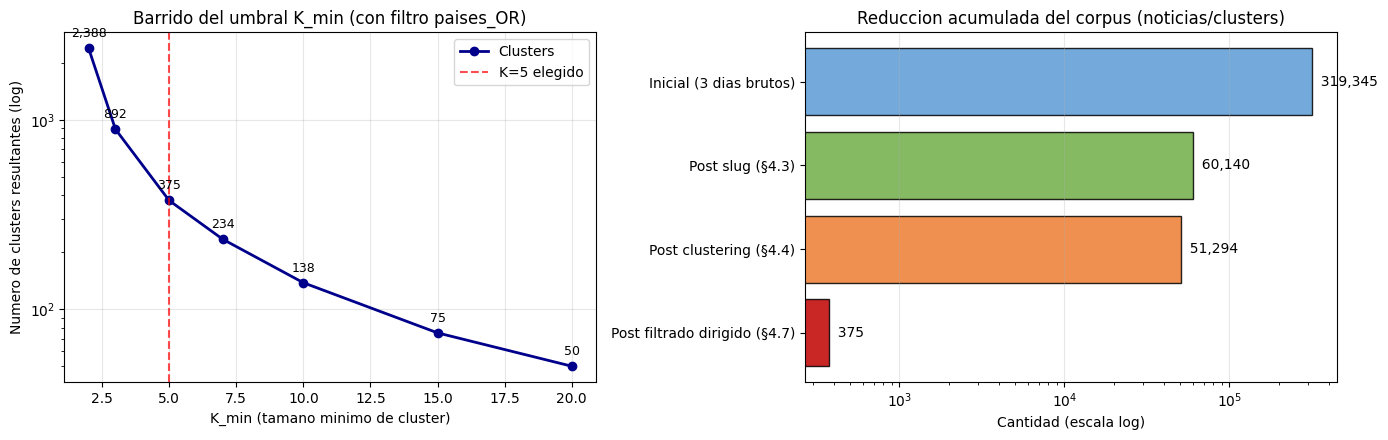

In [25]:
import matplotlib.pyplot as plt

# --- Panel izquierdo: barrido de K_min ---
K_vals = [2, 3, 5, 7, 10, 15, 20]
n_clusters_K, n_filas_K = [], []
for K in K_vals:
    cv = set(tam_cluster[tam_cluster >= K].index)
    sub = df_all[df_all["cluster_global"].isin(cv) & mask_paises]
    n_clusters_K.append(sub["cluster_global"].nunique())
    n_filas_K.append(len(sub))

# --- Panel derecho: funnel de reduccion ---
n_inicial_total = sum(r[2]["filas_iniciales"] for r in resultados.values())
etapas = [
    "Inicial (3 dias brutos)",
    "Post slug (§4.3)",
    "Post clustering (§4.4)",
    "Post filtrado dirigido (§4.7)",
]
noticias = [
    n_inicial_total,
    df_all["url_norm"].nunique(),
    df_all["cluster_global"].nunique(),
    df_grafo["cluster_global"].nunique(),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(K_vals, n_clusters_K, marker="o", color="darkblue",
         linewidth=2, label="Clusters")
ax1.set_xlabel("K_min (tamano minimo de cluster)")
ax1.set_ylabel("Numero de clusters resultantes (log)")
ax1.set_yscale("log")
ax1.axvline(5, color="red", linestyle="--", alpha=0.7, label="K=5 elegido")
ax1.set_title("Barrido del umbral K_min (con filtro paises_OR)")
ax1.grid(alpha=0.3)
ax1.legend()
for K, n in zip(K_vals, n_clusters_K):
    ax1.annotate(f"{n:,}", (K, n), textcoords="offset points",
                  xytext=(0, 8), ha="center", fontsize=9)

colores = ["#5b9bd5", "#70ad47", "#ed7d31", "#c00000"]
bars = ax2.barh(etapas[::-1], noticias[::-1], color=colores[::-1],
                 edgecolor="black", alpha=0.85)
ax2.set_xscale("log")
ax2.set_xlabel("Cantidad (escala log)")
ax2.set_title("Reduccion acumulada del corpus (noticias/clusters)")
for bar, v in zip(bars, noticias[::-1]):
    ax2.text(v, bar.get_y() + bar.get_height() / 2,
              f"  {v:,}", va="center", fontsize=10)
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


**Resultado.** El DataFrame `df_grafo` queda como el conjunto de
trabajo final para los pasos de modelado. Cada fila representa un
**evento GDELT** (potencial arista del grafo, dirigida `Actor1→Actor2`)
asignado a una **noticia** (`cluster_global`) cuyo tamaño cuantifica la
intensidad de cobertura mediática.

Las decisiones de modelado pendientes (cómo agregar las filas a aristas
del grafo dinámico, cómo ponderar por tamaño de cluster, cómo usar
`GoldsteinScale` y `AvgTone` como atributos de arista) son objeto del
capítulo siguiente y de las decisiones del acta §2.4. Aquí terminamos la
fase de tratamiento de datos.


### 4.7 LDA — temas latentes

Tras la limpieza por contenido (§4.1–§4.4) y la reducción dirigida al
grafo (§4.6), se aplica un **modelado de tópicos latentes** (Latent
Dirichlet Allocation, Blei et al. 2003) sobre el corpus de textos
sintéticos. El objetivo es complementar el clustering estructural de
§4.4 con una **partición temática suave**: cada documento se representa
como una distribución de probabilidad sobre *k* tópicos, y cada tópico
como una distribución sobre el vocabulario. Esta representación puede
incorporarse posteriormente como *feature* de las aristas del grafo
(intensidad temática del evento) o de los nodos (perfil agregado del
país).

**Precauciones específicas del corpus GDELT:**

1. **El texto sintético es pobre** (~18 tokens/documento) frente a un
   LDA clásico sobre artículos completos. Los tópicos resultantes
   tienden a estar dominados por nombres de actor y descriptores
   geográficos más que por temáticas noticiosas en sentido amplio.
2. **Las palabras del propio etiquetado CAMEO** (`cooperation`, `conflict`,
   `threaten`, etc.) aparecen en casi todos los documentos. Si no se
   filtran como *stopwords*, dominan los tópicos artificialmente. Lo
   mismo ocurre con las *stopwords* específicas de URLs del paso §4.3.
3. **El vocabulario se restringe** a términos alfabéticos de ≥ 3
   caracteres que aparecen al menos en 10 documentos y en menos del
   50 % del corpus, para evitar ruido.

**Granularidad.** Se entrena el LDA sobre los textos únicos por URL del
corpus combinado de los tres días (~60 000 documentos), igual que para
los embeddings de §4.4, para evitar inflación artificial por repetición.

**Elección de `k`.** Se realiza un barrido con `k ∈ {10, 15, 20}`,
entrenando un LDA *online* durante 15 iteraciones y reportando la
perplejidad. Para `k = 10` los tópicos agrupan regiones excesivamente
amplias; para `k = 20` empiezan a fragmentarse. **Se elige `k = 15`**
como compromiso entre granularidad y coherencia.


In [30]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Corpus: un documento por URL unica
corpus_lda = df_all.drop_duplicates(subset="url_norm")["texto"].tolist()
print(f"Documentos unicos para LDA: {len(corpus_lda):,}")

# Stopwords combinadas: ingles + URL slug + palabras del propio etiquetado CAMEO
stop_cameo = set()
for frase in list(CAMEO_ROOT.values()) + list(QUAD_CLASS.values()):
    stop_cameo.update(frase.split())
stop_total = list(ENGLISH_STOP_WORDS | _STOP_SLUG | stop_cameo)
print(f"Stopwords combinadas: {len(stop_total)}")

# Bag-of-words
cv = CountVectorizer(stop_words=stop_total, min_df=10, max_df=0.5,
                     max_features=20000, token_pattern=r"[a-z]{3,}")
X_bow = cv.fit_transform(corpus_lda)
print(f"Matriz BoW: {X_bow.shape}")

# Entrenamiento LDA k=15
K_LDA = 15
lda = LatentDirichletAllocation(n_components=K_LDA, learning_method="online",
                                 random_state=0, max_iter=15, n_jobs=1)
doc_topic = lda.fit_transform(X_bow)
print(f"Perplejidad: {lda.perplexity(X_bow):.0f}")

vocab = np.array(cv.get_feature_names_out())
print("\nTOPICOS (top 12 palabras):")
for t in range(K_LDA):
    top_words = vocab[lda.components_[t].argsort()[::-1][:12]]
    n_docs = int((doc_topic.argmax(axis=1) == t).sum())
    print(f"  T{t:>2}  ({n_docs:>5,} docs)  {' '.join(top_words)}")


Documentos unicos para LDA: 60,140
Stopwords combinadas: 385
Matriz BoW: (60140, 7889)
Perplejidad: 2239

TOPICOS (top 12 palabras):
  T 0  (3,306 docs)  israel general media bank chief west gaza lebanon british arab israeli emirates
  T 1  (3,794 docs)  india delhi new pradesh minist governor senate colorado federal global michigan ece
  T 2  (2,003 docs)  business university day cuba administration oklahoma singapore travel kansas arrest tax hawaii
  T 3  (4,434 docs)  states united columbia district washington government house illinois american spain home pennsylvania
  T 4  (2,865 docs)  france italy general nation philippines college death malaysia worker manila karnataka meeting
  T 5  (2,449 docs)  police state pakistan hospital industry year mexico arrested government maine old department
  T 6  (3,326 docs)  south australia company new russia wales japan high white life western family
  T 7  (3,554 docs)  canada ireland residents ontario business military dublin toronto calls 

**Asignación a las noticias filtradas (§4.6).** Se asigna a cada
noticia (`cluster_global`) el **tópico dominante** de su documento
representativo: el tópico de mayor probabilidad en la distribución
inferida. Esto cuantifica la composición temática del corpus filtrado.


In [31]:
url_a_topico = pd.Series(doc_topic.argmax(axis=1),
                          index=df_all.drop_duplicates(subset="url_norm")["url_norm"])

texto_por_cluster = df_grafo.groupby("cluster_global").agg(
    url=("url_norm", "first"),
    fecha=("fecha", "first"),
    texto=("texto", "first"),
).reset_index()
texto_por_cluster["topico"] = texto_por_cluster["url"].map(url_a_topico)
dist_topicos = texto_por_cluster["topico"].value_counts().sort_index()

print(f"Distribucion de topicos sobre {len(texto_por_cluster)} noticias filtradas:\n")
print(f"{'T':>3}  {'n_noticias':>10}  ejemplo")
for t in range(K_LDA):
    n = int(dist_topicos.get(t, 0))
    if n == 0:
        print(f"  T{t:>2}  {0:>10}  (sin noticias)")
        continue
    ejemplo = texto_por_cluster[texto_por_cluster["topico"] == t].iloc[0]["texto"]
    print(f"  T{t:>2}  {n:>10}  {ejemplo[:90]}")


Distribucion de topicos sobre 375 noticias filtradas:

  T  n_noticias  ejemplo
  T 0          30  mamata banerjee appears calcutta lawyers robes over poll violence case seeks immediate pro
  T 1          32  modi meets russian iranian brazilian other brics prime minister russia new delhi, delhi, i
  T 2          14  americas cia director meets cuba interior minister intl latam cuban a us havana, ciudad de
  T 3          28  liberals drop signature insurance company promise tasmania australia disapprove verbal con
  T 4          15  breakingnews gunfire breaks out philippine senate where authorities have tried arrest sena
  T 5           9  fbi sought interview milwaukee county elections director official milwaukee milwaukee coun
  T 6          42  teen walks free after sharing propaganda online melbourne police leeton, new south wales, 
  T 7          21  alberta premier calls judges decision separation petition anti democratic alberta province
  T 8          24  markets commodities i

**Visualización.**


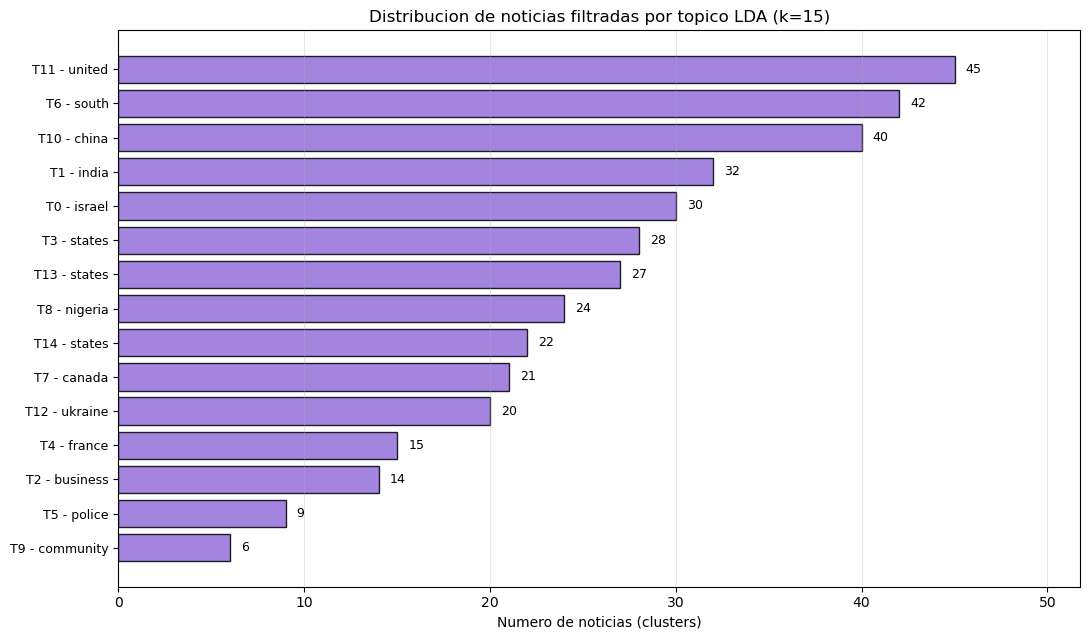

In [32]:
import matplotlib.pyplot as plt

K_LDA = getattr(lda, "n_components", len(dist_topicos))
fig, ax = plt.subplots(figsize=(11, 6.5))
topicos_ord = list(range(K_LDA))
counts = [int(dist_topicos.get(t, 0)) for t in topicos_ord]
top_words_str = [vocab[lda.components_[t].argsort()[::-1][0]]
                 for t in topicos_ord]
orden = sorted(range(K_LDA), key=lambda t: counts[t])
labels = [f"T{t} - {top_words_str[t]}" for t in orden]
counts_ord = [counts[t] for t in orden]

ax.barh(labels, counts_ord, color="mediumpurple", edgecolor="black", alpha=0.85)
ax.set_xlabel("Numero de noticias (clusters)")
ax.set_title(f"Distribucion de noticias filtradas por topico LDA (k={K_LDA})")
ax.grid(axis="x", alpha=0.3)
ax.tick_params(axis="y", labelsize=9)
for i, n in enumerate(counts_ord):
    if n > 0:
        ax.text(n + 0.6, i, str(n), va="center", fontsize=9)
ax.set_xlim(0, max(counts_ord) * 1.15)
plt.tight_layout()
plt.show()


### 4.8 Tabla resumen del pipeline

Consolidación numérica de todas las etapas en una sola tabla, para
incluir directamente en la memoria del TFM.


In [29]:
# Resumen completo del pipeline en un DataFrame
n_inicial_total = sum(r[2]["filas_iniciales"] for r in resultados.values())
n_post_slug_total = sum(r[2]["filas_post_slug"] for r in resultados.values())

filas_resumen = pd.DataFrame([
    {"Etapa": "§3 Carga inicial",
     "Filas": n_inicial_total,
     "Noticias": "—",
     "Reducción": "—",
     "Comentario": "GDELT bruto, 3 dias"},
    {"Etapa": "§4.1 URL normalizada",
     "Filas": n_post_slug_total + sum(r[2]["urls_invalidas"] for r in resultados.values()) + (n_inicial_total - n_post_slug_total - sum(r[2]["urls_invalidas"] for r in resultados.values())),
     "Noticias": "—",
     "Reducción": "0%",
     "Comentario": "SOURCEURL integro, 0 descartes"},
    {"Etapa": "§4.3 Filtro slug >= 3",
     "Filas": n_post_slug_total,
     "Noticias": f"{sum(r[2]['urls_unicas'] for r in resultados.values()):,}".replace(",", " ") + " URLs",
     "Reducción": f"-{100*(n_inicial_total-n_post_slug_total)/n_inicial_total:.1f}%",
     "Comentario": "Filtra URLs basura"},
    {"Etapa": "§4.4 Clustering 0.80",
     "Filas": n_post_slug_total,
     "Noticias": f"{sum(r[2]['n_clusters'] for r in resultados.values()):,}".replace(",", " ") + " clusters",
     "Reducción": "—",
     "Comentario": "Agrupa noticias semanticas"},
    {"Etapa": "§4.7 K>=5 + paises_OR",
     "Filas": len(df_grafo),
     "Noticias": f"{df_grafo['cluster_global'].nunique():,}".replace(",", " ") + " clusters",
     "Reducción": f"-{100*(n_inicial_total-len(df_grafo))/n_inicial_total:.1f}% (filas)",
     "Comentario": "Listo para GNN"},
])
print("Resumen del pipeline:\n")
print(filas_resumen.to_string(index=False))


Resumen del pipeline:

                Etapa  Filas        Noticias      Reducción                     Comentario
     §3 Carga inicial 319345               —              —            GDELT bruto, 3 dias
 §4.1 URL normalizada 319345               —             0% SOURCEURL integro, 0 descartes
§4.3 Filtro slug >= 3 288925     60 163 URLs          -9.5%             Filtra URLs basura
 §4.4 Clustering 0.80 288925 51 294 clusters              —     Agrupa noticias semanticas
§4.7 K>=5 + paises_OR  23247    375 clusters -92.7% (filas)                 Listo para GNN


### 4.9 Listado completo de noticias y nº de veces vistas

Para cerrar el notebook, se lista cada una de las ~375 noticias resultantes
ordenadas de mayor a menor cobertura mediática. Las dos columnas
relevantes son:

- **`Cobertura`**: número de URLs distintas (medios) que cubrieron la
  noticia en el corpus completo antes del filtro de relevancia
  geopolítica. Es la métrica "concurrencia de fenómeno" del filtrado §4.7
  (todas tienen ≥ 5 por definición del filtro A).
- **`Filas`**: número de eventos GDELT generados por esa noticia que
  pasaron el filtro completo (cluster ≥ 5 **y** algún actor en los nodos
  del acta).

Ambas son medidas complementarias del impacto mediático.


In [30]:
# Lista completa de noticias en df_grafo, ordenadas por cobertura total
noticias_finales = (df_grafo.groupby("cluster_global")
                    .agg(n_filas=("GLOBALEVENTID", "size"),
                         fecha=("fecha", "first"),
                         texto=("texto", "first"))
                    .reset_index())

# Cobertura = tamano original del cluster en df_all (antes del filtro B paises).
# Es la metrica "cuantos medios cubrieron esta noticia".
noticias_finales["cobertura"] = noticias_finales["cluster_global"].map(tam_cluster)
noticias_finales = (noticias_finales
                     .sort_values("cobertura", ascending=False)
                     .reset_index(drop=True))

print(f"Total de noticias en el corpus filtrado: {len(noticias_finales)}\n")
print(f"{'#':>4}  {'Cobertura':>9}  {'Filas':>6}  {'Dia':>10}  Noticia")
print("-" * 145)
for i, row in noticias_finales.iterrows():
    print(f"{i+1:>4}  {row['cobertura']:>9}  {row['n_filas']:>6}  {row['fecha']:>10}  {row['texto'][:110]}")


Total de noticias en el corpus filtrado: 375

   #  Cobertura   Filas         Dia  Noticia
-------------------------------------------------------------------------------------------------------------------------------------------------
   1        459    3645    20260514  china visits nixon trump china united states make public statement verbal cooperation
   2        318    2284    20260515  while trump sought business deals beijing came prepared redefine china relations beijing beijing, beijing, chi
   3        192     371    20260516  nigerian forces eliminate top isis leader abu bilal minuki africa mission trump says united states nigeria keb
   4        158    1243    20260516  trump chinese scholars controversy china china appeal verbal cooperation
   5        107     298    20260515  reports hantavirus cases cruise outbreak united states australia make public statement verbal cooperation
   6         93     257    20260515  cuba cia chief trump message cuba the white house hava